# Notebook 01 — Exploration des données
On commence par explorer le dataset resume-job-description-fit pour comprendre sa structure.

## Imports et chargement

In [1]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.data_utils import load_dataset_fit, group_split

# charger le dataset
df = load_dataset_fit()
df.head()

Dataset chargé: 8000 paires
Colonnes: ['resume_text', 'job_description_text', 'label']


,resume_text,job_description_text,label
0,SummaryHighly motivated Sales Associate with e...,Net2Source Inc. is an award-winning total work...,No Fit
1,Professional SummaryCurrently working with Cat...,At Salas OBrien we tell our clients that were ...,No Fit
2,SummaryI started my construction career in Jun...,Schweitzer Engineering Laboratories (SEL) Infr...,No Fit
3,SummaryCertified Electrical Foremanwith thirte...,"Mizick Miller & Company, Inc. is looking for a...",No Fit
4,SummaryWith extensive experience in business/r...,Life at Capgemini\nCapgemini supports all aspe...,No Fit


## Aperçu du dataset

In [2]:
print(f"Shape: {df.shape}")
print(f"\nColonnes: {list(df.columns)}")
print(f"\nTypes:\n{df.dtypes}")
print(f"\nValeurs manquantes:\n{df.isnull().sum()}")

Shape: (8000, 3)

Colonnes: ['resume_text', 'job_description_text', 'label']

Types:
resume_text             str
job_description_text    str
label                   str
dtype: object

Valeurs manquantes:
resume_text             0
job_description_text    0
label                   0
dtype: int64


## Distribution des labels

Distribution:
label
No Fit           4000
Potential Fit    2000
Good Fit         2000
Name: count, dtype: int64


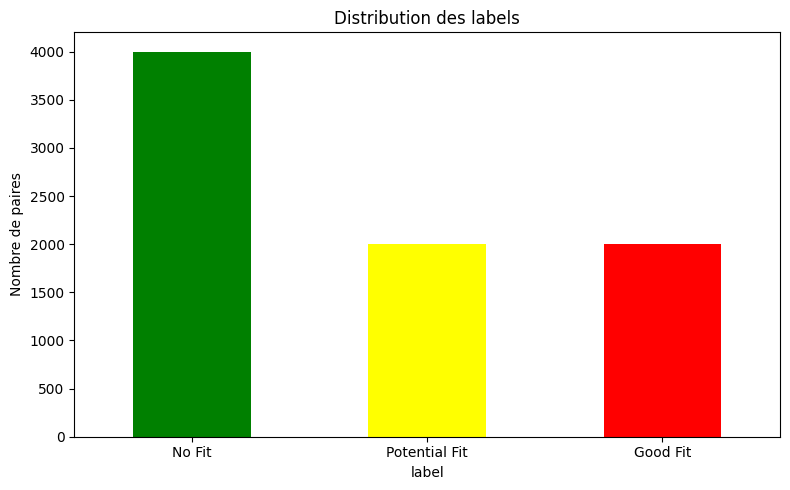

In [11]:
print(f"Distribution:\n{df['label'].value_counts()}")

fig, ax = plt.subplots(figsize=(8, 5))
df['label'].value_counts().plot(kind='bar', ax=ax, color=['green', 'yellow', 'red'])
ax.set_title("Distribution des labels")
ax.set_ylabel("Nombre de paires")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('../figures/label_distribution.png', dpi=150)
plt.show()

## Longueur des textes

On regarde combien de mots contiennent les CVs et les offres, pour savoir si on va dépasser les limites des modèles.

Longueur CVs (mots):
count    8000.000000
mean      704.394250
std       387.030709
min        84.000000
25%       488.000000
50%       618.000000
75%       809.000000
max      3134.000000
Name: cv_len, dtype: float64

Longueur offres (mots):
count    8000.000000
mean      378.439875
std       249.874677
min        11.000000
25%       169.000000
50%       326.000000
75%       552.000000
max      1254.000000
Name: job_len, dtype: float64


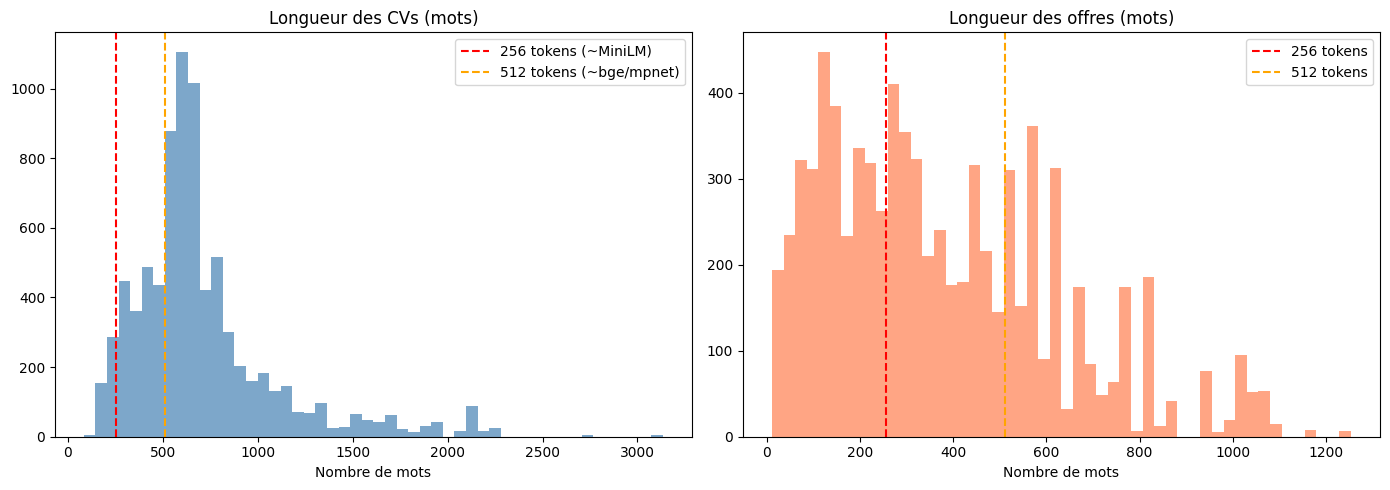


CVs > 256 mots: 7561 (94.5%)
CVs > 512 mots: 5820 (72.8%)
Offres > 256 mots: 4976 (62.2%)
Offres > 512 mots: 2375 (29.7%)


In [12]:
df['cv_len'] = df['resume_text'].str.split().str.len()
df['job_len'] = df['job_description_text'].str.split().str.len()

print(f"Longueur CVs (mots):")
print(df['cv_len'].describe())
print(f"\nLongueur offres (mots):")
print(df['job_len'].describe())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['cv_len'], bins=50, color='steelblue', alpha=0.7)
axes[0].axvline(256, color='red', linestyle='--', label='256 tokens (~MiniLM)')
axes[0].axvline(512, color='orange', linestyle='--', label='512 tokens (~bge/mpnet)')
axes[0].set_title('Longueur des CVs (mots)')
axes[0].set_xlabel('Nombre de mots')
axes[0].legend()

axes[1].hist(df['job_len'], bins=50, color='coral', alpha=0.7)
axes[1].axvline(256, color='red', linestyle='--', label='256 tokens')
axes[1].axvline(512, color='orange', linestyle='--', label='512 tokens')
axes[1].set_title('Longueur des offres (mots)')
axes[1].set_xlabel('Nombre de mots')
axes[1].legend()

plt.tight_layout()
plt.savefig('../figures/text_lengths.png', dpi=150)
plt.show()

# combien de textes dépassent les limites ?
print(f"\nCVs > 256 mots: {(df['cv_len'] > 256).sum()} ({(df['cv_len'] > 256).mean()*100:.1f}%)")
print(f"CVs > 512 mots: {(df['cv_len'] > 512).sum()} ({(df['cv_len'] > 512).mean()*100:.1f}%)")
print(f"Offres > 256 mots: {(df['job_len'] > 256).sum()} ({(df['job_len'] > 256).mean()*100:.1f}%)")
print(f"Offres > 512 mots: {(df['job_len'] > 512).sum()} ({(df['job_len'] > 512).mean()*100:.1f}%)")

## Exemples de paires

On affiche quelques exemples pour voir à quoi ressemblent les données.

In [13]:
# afficher 2 exemples par label
for label in df['label'].unique():
    print(f"\n{'='*80}")
    print(f"LABEL: {label}")
    print(f"{'='*80}")
    samples = df[df['label'] == label].sample(2, random_state=42)
    for i, row in samples.iterrows():
        print(f"\n--- CV (extrait, 200 premiers mots) ---")
        print(' '.join(row['resume_text'].split()[:200]))
        print(f"\n--- Offre (extrait, 200 premiers mots) ---")
        print(' '.join(row['job_description_text'].split()[:200]))
        print()


LABEL: No Fit

--- CV (extrait, 200 premiers mots) ---
Summary7+ years of experience as a BI developer with a proven track record in Business Intelligence (BI), Data Warehouse (DWH) and Data Analytics related consulting projects.Proven ability to identify business needs and develop valuable solutions to drive accuracy and process efficiency.Experienced in developing, implementing, documenting, monitoring and maintaining the data warehouse extracts, transformations and ETL process in various industries like Financial, Health Care and Retail Industry withSales, Marketing, Inventory Management, Supply Chain and Financedomains.Delivered BI reporting solutions in Power BI, Reporting Services (SSRS).Expertise inData Warehousing ArchitecturesincludingETLdesign,Staging,Transformations,Delta/change Datacapture,Star-Schemas, Cubes andHistoryloadingSkilled in writingT-SQL Queries, Dynamic-queries, sub-queries and joins for generatingStored Procedures, Triggers, User-defined Functions, Views and 

## Duplication des CVs

Un même CV peut être associé à plusieurs offres différentes. C'est important pour le split train/test.

In [6]:
n_unique_cvs = df['resume_text'].nunique()
n_unique_jobs = df['job_description_text'].nunique()
print(f"Paires totales: {len(df)}")
print(f"CVs uniques: {n_unique_cvs}")
print(f"Offres uniques: {n_unique_jobs}")
print(f"\nEn moyenne, chaque CV apparaît {len(df)/n_unique_cvs:.1f} fois")
print(f"En moyenne, chaque offre apparaît {len(df)/n_unique_jobs:.1f} fois")

# c'est pour ça qu'on a besoin du group split !

Paires totales: 8000
CVs uniques: 643
Offres uniques: 351

En moyenne, chaque CV apparaît 12.4 fois
En moyenne, chaque offre apparaît 22.8 fois


## Group split

On utilise `group_split()` pour séparer train/test en s'assurant qu'un même CV n'apparaît pas dans les deux.

CVs uniques: 643 pour 8000 paires
Train: 6595 | Test: 1405
Overlap CVs train/test: 0 (doit être 0)

Distribution labels TRAIN:
label
No Fit           0.497953
Good Fit         0.252312
Potential Fit    0.249735
Name: proportion, dtype: float64

Distribution labels TEST:
label
No Fit           0.509609
Potential Fit    0.251246
Good Fit         0.239146
Name: proportion, dtype: float64


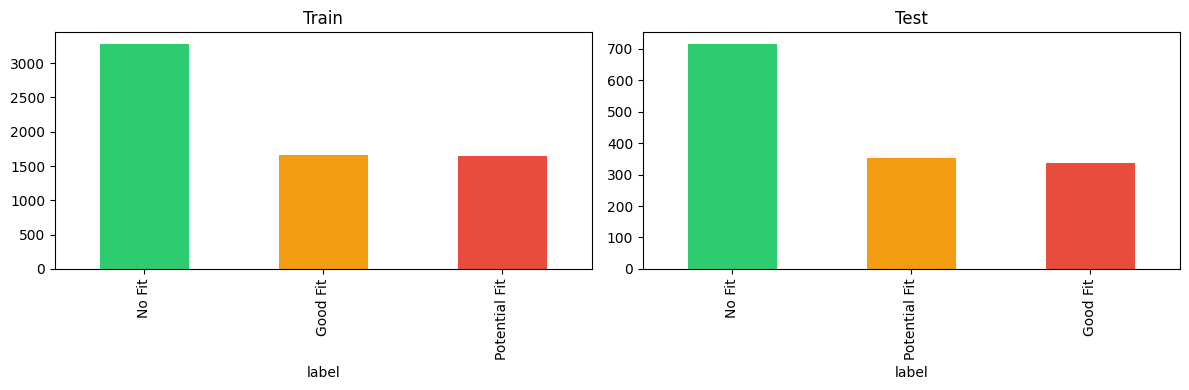

In [15]:
train_df, test_df = group_split(df)

print(f"\nDistribution labels TRAIN:\n{train_df['label'].value_counts(normalize=True)}")
print(f"\nDistribution labels TEST:\n{test_df['label'].value_counts(normalize=True)}")

# vérifier visuellement
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
train_df['label'].value_counts().plot(kind='bar', ax=axes[0], color=['#2ecc71', '#f39c12', '#e74c3c'])
axes[0].set_title('Train')
test_df['label'].value_counts().plot(kind='bar', ax=axes[1], color=['#2ecc71', '#f39c12', '#e74c3c'])
axes[1].set_title('Test')
plt.tight_layout()
plt.savefig('../figures/split_distribution.png', dpi=150)
plt.show()